In [1]:
import operator
from typing import TypedDict, List, Annotated
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END 
from langgraph.types import Send
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage


In [2]:
class Task(BaseModel):
    id: int 
    title: str
    brief: str = Field(..., description="What to cover")

In [4]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [5]:
class State(TypedDict):
    topic: str
    plan: Plan
    # reducer: results from workers get concatenated automatically
    sections: Annotated[List[str], operator.add]
    final: str

In [6]:
llm = ChatOpenAI(model="gpt-4.1-mini")

In [7]:
def orchestrator(state: State) -> dict:
    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a blog plan with 5-7 sections on the following topic."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {"plan": plan}

In [8]:
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]

In [9]:
def worker(payload: dict) -> dict:

    # payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [14]:
import re
from pathlib import Path

def reducer(state: State) -> dict:
    
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ---- save to file ----
    #Remove illegal characters (like : / \ *) from the title
    safe_title = re.sub(r'[^\w\s-]', '', title)
    filename = safe_title.lower().replace(" ", "_") + ".md"
    
    # FIX 2: Explicitly tie the file to the current working directory
    output_path = Path.cwd() / filename
    
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [15]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

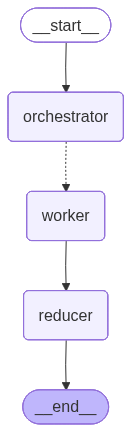

In [16]:
g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

app

In [17]:
out = app.invoke({"topic": "Write a blog on Self Attention", "sections": []})

In [19]:
out

{'topic': 'Write a blog on Self Attention',
 'plan': Plan(blog_title='Understanding Self-Attention Mechanism in Deep Learning', tasks=[Task(id=1, title='Introduction to Self-Attention', brief='Explain what self-attention is and its role in deep learning models.'), Task(id=2, title='How Self-Attention Works', brief='Describe the mechanics of self-attention, including queries, keys, and values.'), Task(id=3, title='Mathematical Formulation', brief='Provide the mathematical equations that define self-attention computations.'), Task(id=4, title='Advantages of Self-Attention', brief='Discuss the benefits of self-attention over traditional sequence models like RNNs and CNNs.'), Task(id=5, title='Applications of Self-Attention', brief='Highlight important use cases such as in transformers, NLP, and computer vision.'), Task(id=6, title='Challenges and Future Directions', brief='Address current limitations and potential improvements in self-attention research.'), Task(id=7, title='Conclusion', 

In [18]:
print(out["final"])

# Understanding Self-Attention Mechanism in Deep Learning

## Introduction to Self-Attention

Self-attention is a powerful mechanism in deep learning that enables models to weigh the importance of different parts of the input data relative to each other. Unlike traditional sequential processing methods, self-attention allows a model to directly consider the relationships and dependencies between all elements in a sequence simultaneously. This capability is especially crucial for tasks involving natural language processing, where understanding context and long-range dependencies can significantly improve model performance.

At its core, self-attention computes a set of attention scores between each element in the input and every other element, effectively capturing how much focus should be placed on different parts of the input when producing an output. By doing so, it allows models to dynamically highlight relevant information and suppress less important details, leading to more nuance